In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import grangercausalitytests
import seaborn as sns



In [17]:
# Read in targets
targets_df = pd.read_csv('targets.csv')
targets_df['Date'] = pd.to_datetime(targets_df['Date'])
targets_df.set_index('Date', inplace=True)

# Read in predictors
predictors_df = pd.read_csv('predictors.csv')
predictors_df['Date'] = pd.to_datetime(predictors_df['Date'])
predictors_df.set_index('Date', inplace=True)

# Merge targets and predictors
merged_df = targets_df.join(predictors_df)
print(merged_df)

                     SO2    Auto Gas  Basic Chemicals    Fuel Oil  \
Date                                                                
1980-01-01  9.442626e-07   80.378294        86.835593   74.154677   
1980-04-01  9.340424e-07   74.045325        85.576519   66.056135   
1980-07-01  9.258992e-07   73.681244        80.152687   67.456106   
1980-10-01  9.199498e-07   73.421459        84.307597   70.289212   
1981-01-01  9.140747e-07   73.734122        86.152397   71.410456   
...                  ...         ...              ...         ...   
2022-10-01  3.424376e-07   98.531831        95.815294  102.555111   
2023-01-01  3.424159e-07   95.767037        99.619374   94.950619   
2023-04-01  3.424292e-07  101.908704        99.798314   99.925258   
2023-07-01  3.424477e-07  101.979881       100.576745  101.991806   
2023-10-01  3.424376e-07  100.344378       100.005567  103.132316   

            Manufacturing  Pave Roof PC  Petrol Coal  Total Population  \
Date                        

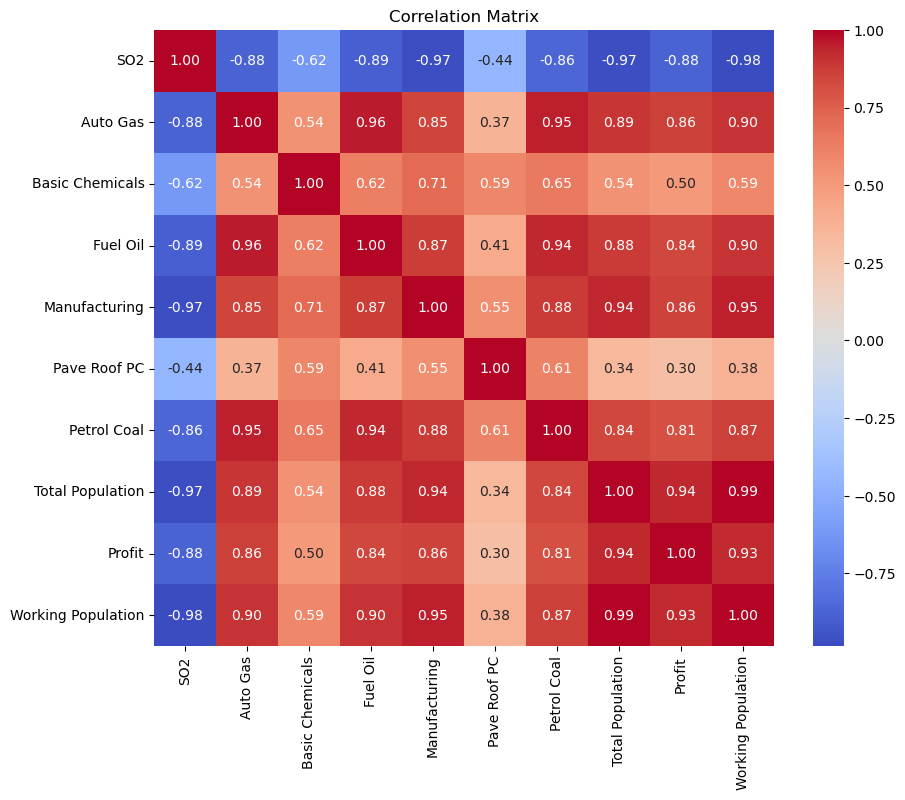

In [18]:
# Calculate correlation matrix
correlation_matrix = merged_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [19]:
# print(correlation_matrix)
# Features to include in analysis: 'Auto Gas', 'Fuel Oil', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population'. 
# Given that the SO2 emissions are decreasing with increasing production index of industrial manufacturing sectors, corporate profit, and working population, 
# We now hypothesize that there are external factors that might be linked to the reduction of SO2 such as environmental regulation.
# We suggest that future work includes an analysis of environmental regulatory data in order to determine what role environmental protection efforts play in the results we presented here. 


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

selected_predictors = ['Auto Gas', 'Fuel Oil', 'Manufacturing', 'Petrol Coal', 'Profit', 'Working Population']

# Calculate VIF for each predictor
X = merged_df[selected_predictors]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print(vif_data)

              Feature          VIF
0            Auto Gas  1286.503861
1            Fuel Oil   303.960934
2       Manufacturing   145.944004
3         Petrol Coal   801.727738
4              Profit    26.117878
5  Working Population   428.876507


In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


def perform_STL(df, feature):
    # Perform STL decomposition
    decomposition = seasonal_decompose(df[feature], model='multiplicative')

    # Visualize the components
    plt.figure(figsize=(10, 6))

    plt.subplot(411)
    plt.plot(decomposition.observed, label='Observed')
    plt.legend(loc='upper left')

    plt.subplot(412)
    plt.plot(decomposition.trend, label='Trend')
    plt.legend(loc='upper left')

    plt.subplot(413)
    plt.plot(decomposition.seasonal, label='Seasonal')
    plt.legend(loc='upper left')

    plt.subplot(414)
    plt.plot(decomposition.resid, label='Residual')
    plt.legend(loc='upper left')

    plt.suptitle(f'STL Decomposition of {feature}')
    plt.tight_layout()
    plt.show()

def perform_multi_STL(df, features):
    # Create subplots
    fig, axs = plt.subplots(4, 1, figsize=(20, 10))

    # Perform STL decomposition for each feature
    for feature in features:
        decomposition = seasonal_decompose(df[feature], model='multiplicative')

        # Plot observed
        axs[0].plot(decomposition.observed, label=feature)
        axs[0].set_title('Observed')
        axs[0].legend(loc='upper left')

        # Plot trend
        axs[1].plot(decomposition.trend, label=feature)
        axs[1].set_title('Trend')
        axs[1].legend(loc='upper left')

        # Plot seasonal
        axs[2].plot(decomposition.seasonal, label=feature)
        axs[2].set_title('Seasonal')
        axs[2].legend(loc='upper left')

        # Plot residual
        axs[3].plot(decomposition.resid, label=feature)
        axs[3].set_title('Residual')
        axs[3].legend(loc='upper left')

    # Set common title and adjust layout
    plt.suptitle('')
    plt.tight_layout()
    plt.show()


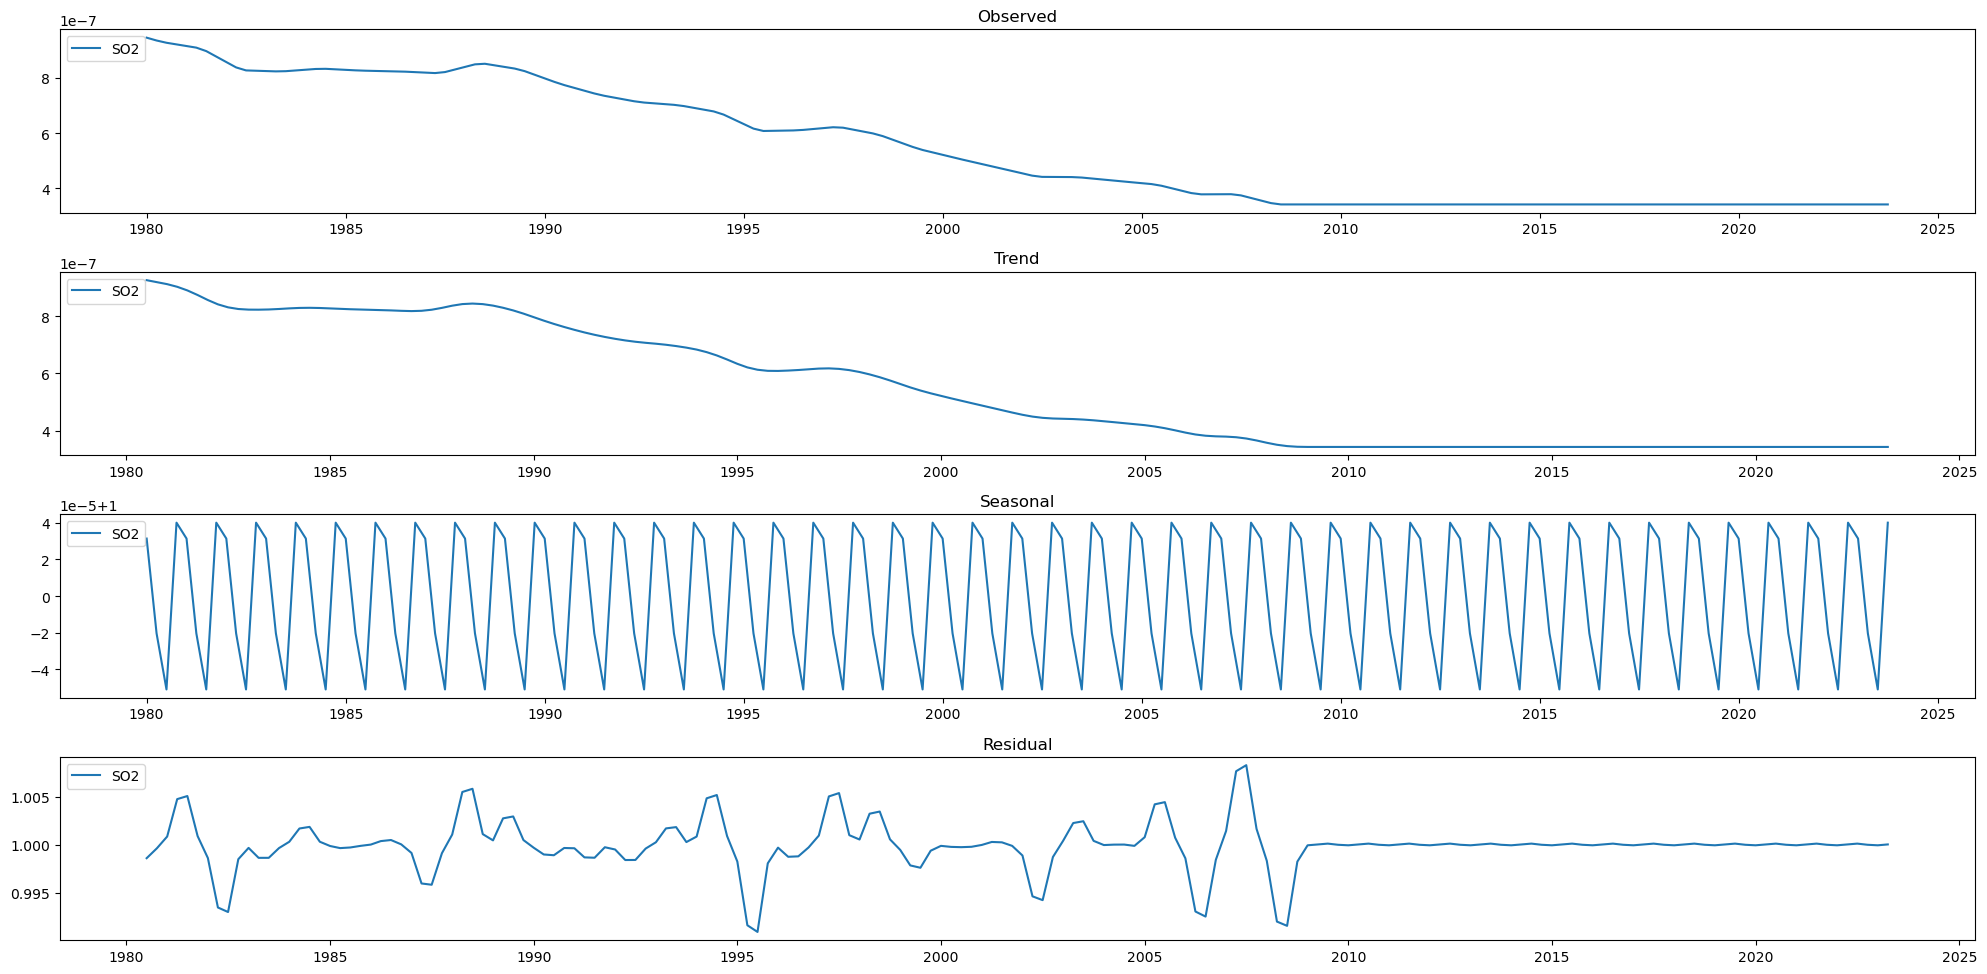

In [96]:
# perform_STL(merged_df, 'SO2')
perform_multi_STL(merged_df, ['SO2'])


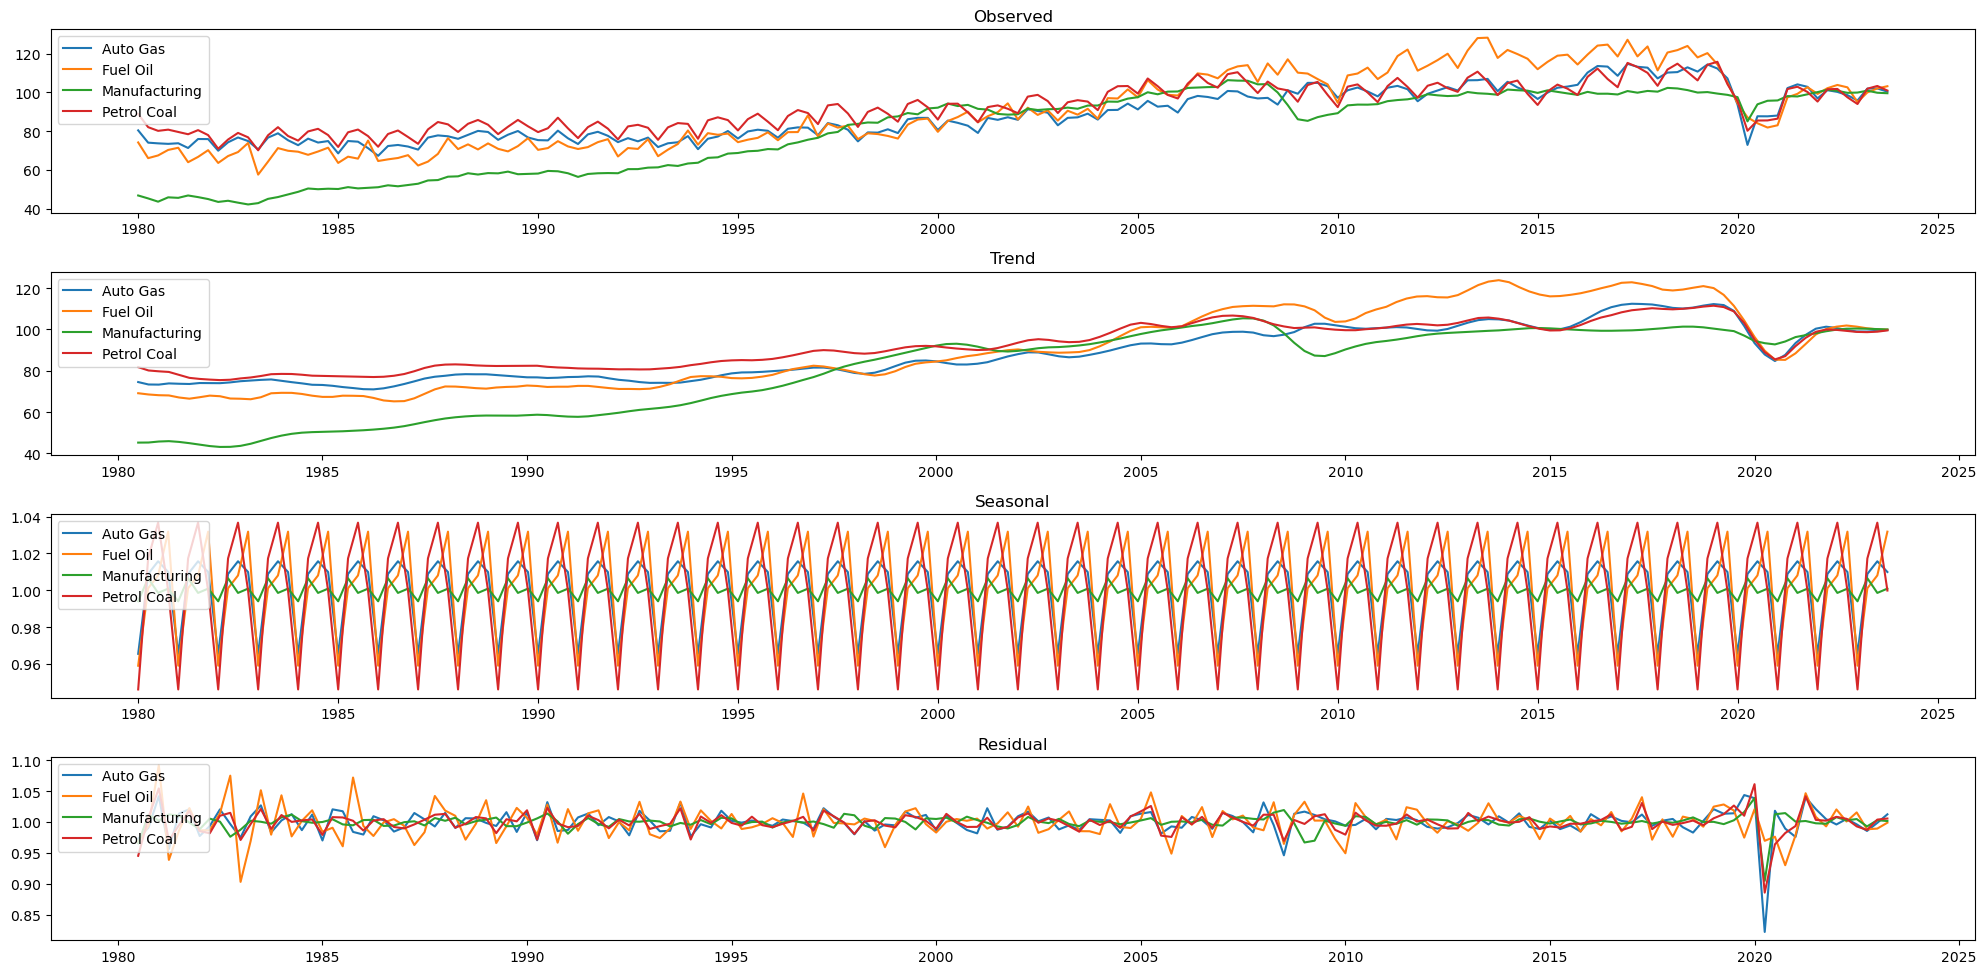

In [97]:
 # Call the function to perform STL decomposition and plot the selected predictors
perform_multi_STL(predictors_df, ['Auto Gas', 'Fuel Oil', 'Manufacturing', 'Petrol Coal'])  # maybe let's leave out fuel oil because it's pretty much the same as auto gas, but it appears to have a lag that I don't want to deal with. 


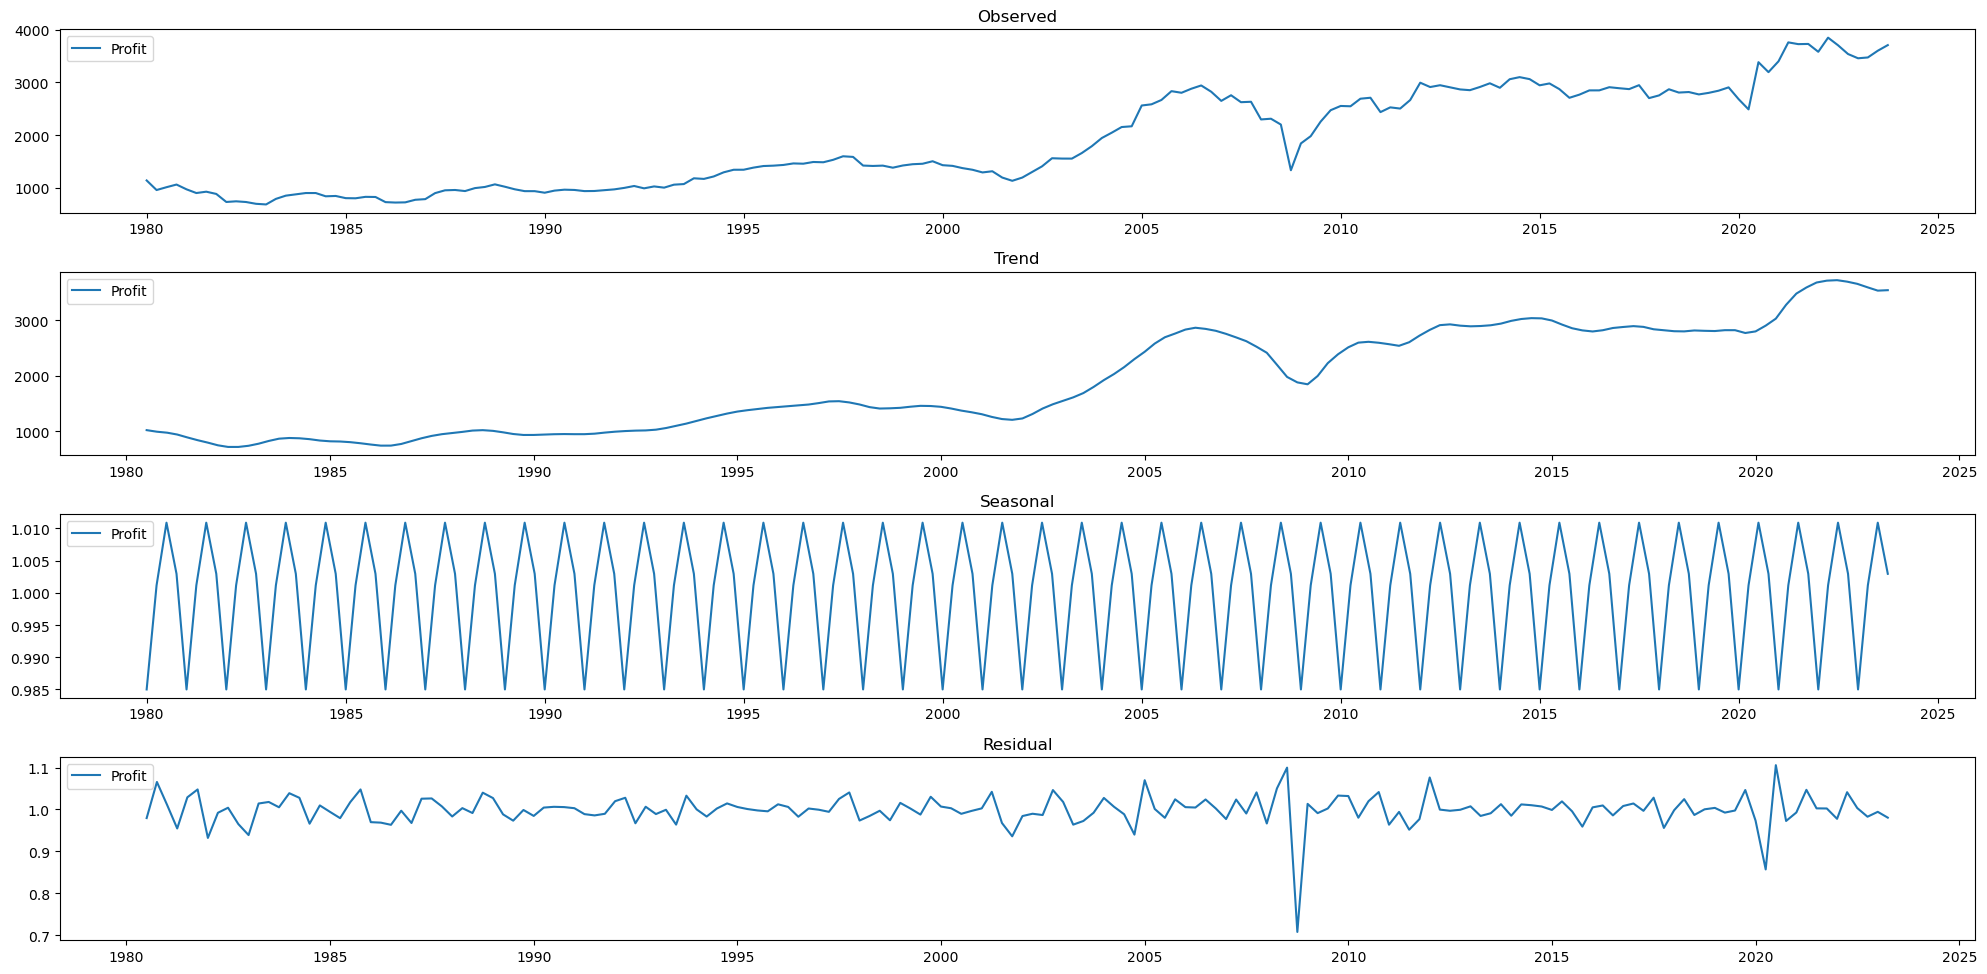

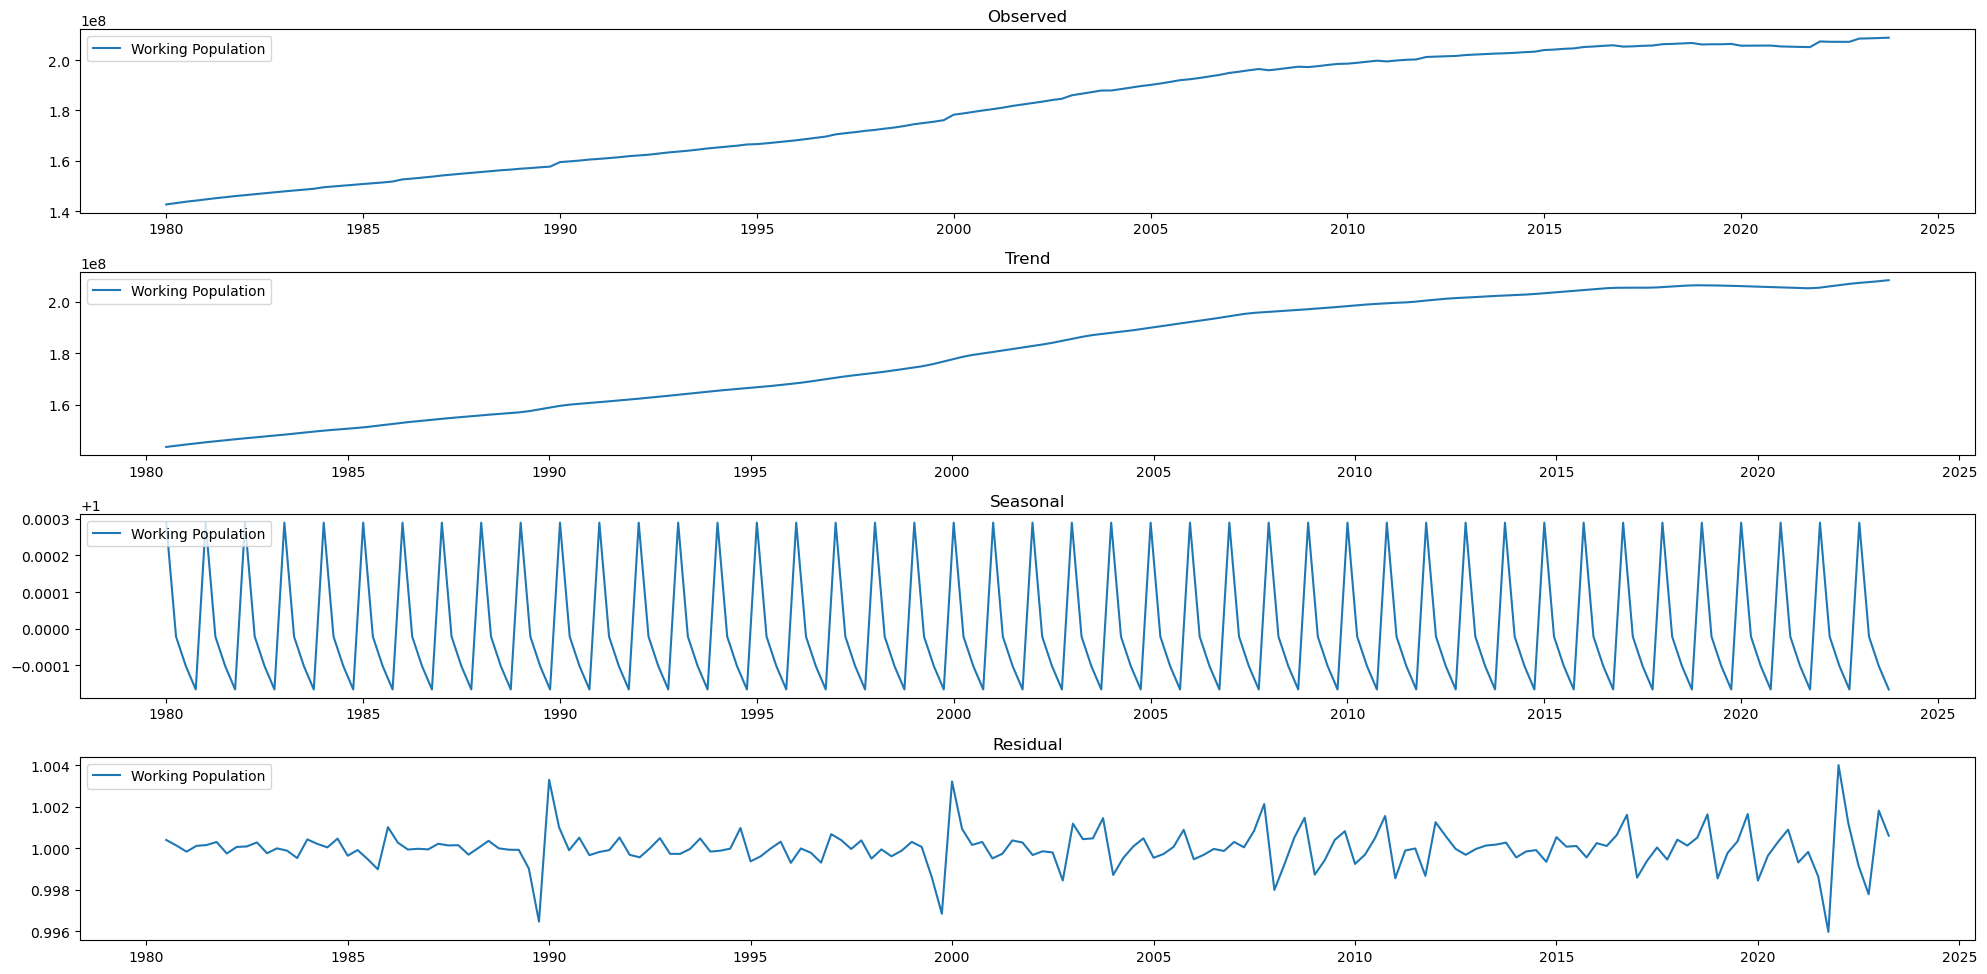

In [94]:
# Workers
perform_multi_STL(predictors_df, ['Profit'])              # Trend looks linear, but we used multiplicative for the sake of consistency (Profit and Working Pop both look linearish)
perform_multi_STL(predictors_df, ['Working Population'])  # Trend looks linear, but we used multiplicative for the sake of consistency
